In [1]:
import pandas as pd
import ast
import os

In [2]:
os.environ['R_HOME'] = '/home/ZHX/anaconda3/envs/GraphST/lib/R'
current_path = os.getcwd()
print("当前路径：", current_path)
file_path=current_path

当前路径： /home/ZHX/code111/GraphST-main/stCCL/Tutorial


In [3]:
# 读取Excel文件
df = pd.read_excel('/home/ZHX/code111/GraphST-main/final_result/DLPFC_result3.xlsx', engine='openpyxl',sheet_name='ARI',index_col=0)  # 指定引擎为openpyxl以处理.xlsx文件
df2 = pd.read_excel('/home/ZHX/code111/GraphST-main/final_result/DLPFC_result3.xlsx', engine='openpyxl',sheet_name='NMI',index_col=0)  # 指定引擎为openpyxl以处理.xlsx文件

# 显示DataFrame的内容
print(df)
print(df2)
result_path = "/home/ZHX/code111/GraphST-main/final_result/result_visualization3/"

          SCANPY   STAGATE      SEDR    MuCoST   SpaNCMG   GraphST  SpatialDG  \
slice                                                                           
151507  0.334461  0.530045  0.492608  0.474496  0.485173  0.477920   0.733612   
151508  0.316041  0.513626  0.501629  0.489397  0.457870  0.506948   0.528800   
151509  0.252854  0.486830  0.508992  0.488338  0.472901  0.402382   0.658344   
151510  0.365941  0.474296  0.447986  0.509342  0.474703  0.509620   0.490835   
151669  0.197470  0.528670  0.398849  0.488605  0.522517  0.478967   0.317892   
151670  0.203648  0.386427  0.313678  0.371796  0.514166  0.452184   0.421001   
151671  0.279378  0.585821  0.618768  0.610406  0.572237  0.633543   0.747636   
151672  0.327288  0.562504  0.729961  0.622079  0.579564  0.628236   0.548222   
151673  0.329325  0.561786  0.579467  0.569730  0.586847  0.627692   0.586369   
151674  0.362641  0.432621  0.535272  0.613123  0.452566  0.468323   0.528770   
151675  0.300671  0.437512  

In [4]:
df.mean()


SCANPY       0.292891
STAGATE      0.490707
SEDR         0.515453
MuCoST       0.526339
SpaNCMG      0.519985
GraphST      0.514148
SpatialDG    0.543805
stCCL        0.551424
dtype: float64

In [5]:
df2.mean()

SCANPY       0.398080
STAGATE      0.625600
SEDR         0.651142
MuCoST       0.663833
SpaNCMG      0.640688
GraphST      0.647203
SpatialDG    0.632101
stCCL        0.679870
dtype: float64

In [6]:
df.median()

SCANPY       0.304514
STAGATE      0.495101
SEDR         0.508974
MuCoST       0.524984
SpaNCMG      0.519227
GraphST      0.499953
SpatialDG    0.541362
stCCL        0.548356
dtype: float64

In [7]:
df2.median()

SCANPY       0.403700
STAGATE      0.645146
SEDR         0.662695
MuCoST       0.666935
SpaNCMG      0.634835
GraphST      0.650862
SpatialDG    0.651188
stCCL        0.680353
dtype: float64

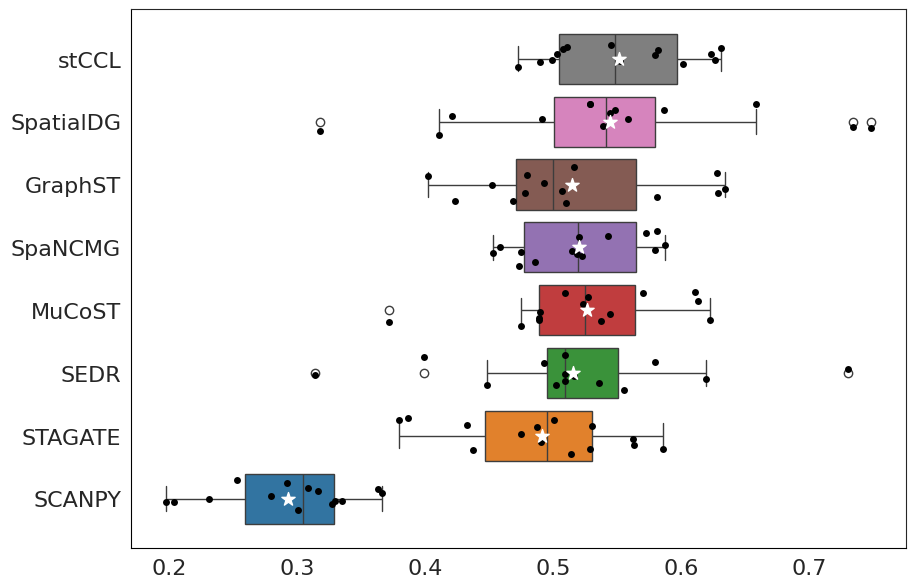

In [8]:
#绘制12张切片ARI的水平箱线图和散点图
import matplotlib.pyplot as plt
import xlrd
import seaborn as sns
import matplotlib as mpl
sns.set_style("white")  # 设置背景为白色
colors = sns.color_palette(n_colors=7)
mpl.rcParams.update({'font.size': 16})
plt.figure(figsize=(10, 7))

ax = sns.boxplot(data=df, orient='h')
ax = sns.stripplot(data=df,orient='h',color='black' ,jitter=0.3, size=5)
mean = df.mean()
ax.set_ylabel('',rotation=0, labelpad=50, va='center')
for i, val in enumerate(mean):
    ax.scatter(val, i, color='white', s=100, marker='*',zorder=10, label=f'Mean {df.columns[i]}')
# 倒序 y 轴
ax.invert_yaxis()
# ax.set_title("DLPFC")

# 设置边框样式
ax.spines['top'].set_visible(True)    # 移除上边框
ax.spines['right'].set_visible(True)  # 移除右边框
ax.spines['bottom'].set_visible(True)  # 保留下边框
ax.spines['left'].set_visible(True)    # 保留左边框

# 设置边框颜色为黑色
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# 移除网格线（内框线）
ax.grid(False)

plt.savefig(os.path.join(result_path,"DLPFC_ARI_h_box_strip3.png"))

plt.show()


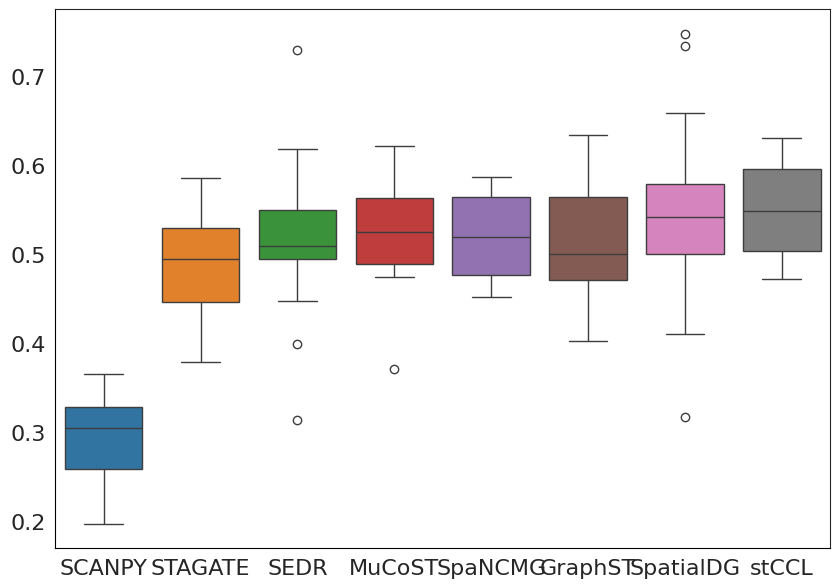

In [9]:
#绘制12张切片ARI的垂直箱线图和散点图
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import os

# 设置颜色和字体
sns.set_style("white")  # 设置背景为白色
colors = sns.color_palette(n_colors=7)
mpl.rcParams.update({'font.size': 16})
# 创建图像（设置图像大小）
plt.figure(figsize=(10, 7))  # 宽 10 英寸，高 8 英寸

# 绘制垂直箱线图
ax = sns.boxplot(data=df, orient='v')

# 计算均值
mean = df.mean()
# 清空 y 轴标签（不是必须）
ax.set_xlabel('', labelpad=50)
# ax.set_title("ARI")

# 设置边框样式
ax.spines['top'].set_visible(True)    # 移除上边框
ax.spines['right'].set_visible(True)  # 移除右边框
ax.spines['bottom'].set_visible(True)  # 保留下边框
ax.spines['left'].set_visible(True)    # 保留左边框

# 设置边框颜色为黑色
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# 保存图像
plt.savefig(os.path.join(result_path, "DLPFC_ARI_v_box_strip3.png"), bbox_inches='tight')

# 显示图形
plt.show()

In [10]:
df.mean()

SCANPY       0.292891
STAGATE      0.490707
SEDR         0.515453
MuCoST       0.526339
SpaNCMG      0.519985
GraphST      0.514148
SpatialDG    0.543805
stCCL        0.551424
dtype: float64

/tmp/ipykernel_1636321/689435462.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=mean_values.index, y=mean_values.values, palette='Set2')


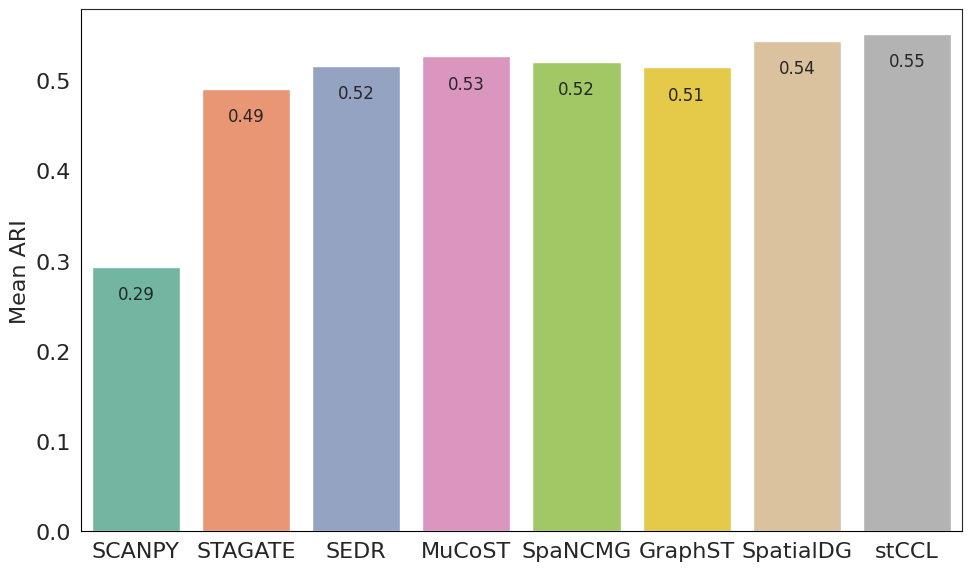

In [11]:
#绘制12张切片ARI均值的柱状图
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 计算每列的均值
mean_values = df.mean()

# 创建图像并设置大小
# 设置颜色和字体
sns.set_style("white")  # 设置背景为白色
colors = sns.color_palette(n_colors=7)
mpl.rcParams.update({'font.size': 16})
plt.figure(figsize=(10, 6))

# 绘制柱状图
ax = sns.barplot(x=mean_values.index, y=mean_values.values, palette='Set2')

# 添加标题和标签
# plt.title("Mean ARI Values for Each Method", fontsize=18)
plt.xlabel("")
plt.ylabel("Mean ARI")

# 旋转 x 轴标签
# plt.xticks(rotation=45, ha='right')
ax.set_xlabel('', labelpad=50)
# 添加每个柱子的数值标签
for i, value in enumerate(mean_values.values):
    ax.text(i, value - 0.02, f"{value:.2f}", ha='center', va='top', fontsize=12)

# 自动调整布局防止遮挡
plt.tight_layout()

# 设置边框样式
ax.spines['top'].set_visible(True)    # 移除上边框
ax.spines['right'].set_visible(True)  # 移除右边框
ax.spines['bottom'].set_visible(True)  # 保留下边框
ax.spines['left'].set_visible(True)    # 保留左边框

# 设置边框颜色为黑色
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# 保存图像
plt.savefig(os.path.join(result_path, "DLPFC_MeanARI_bar3.png"), bbox_inches='tight')

# 显示图形
plt.show()


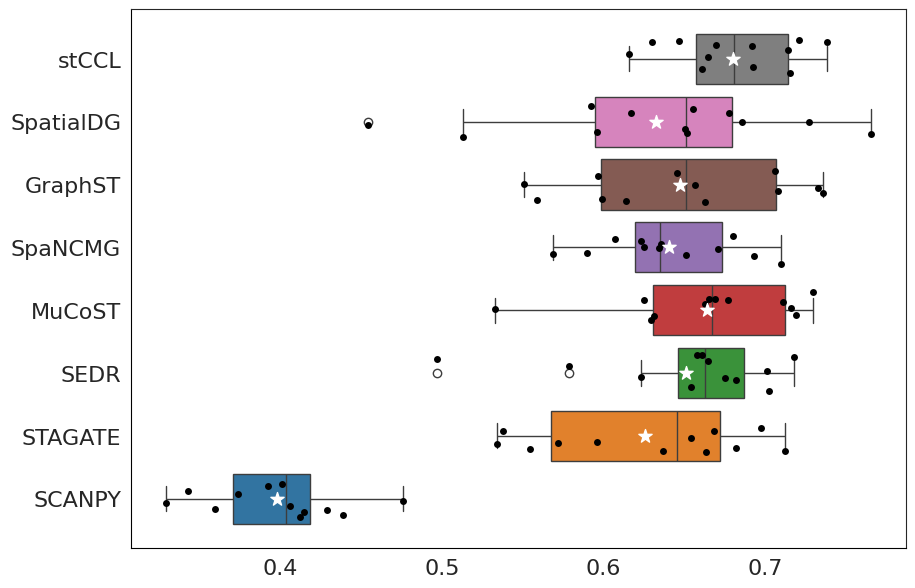

In [12]:
#绘制12张切片NMI的水平箱线图和散点图
import matplotlib.pyplot as plt
import xlrd
import seaborn as sns
import matplotlib as mpl
sns.set_style("white")  # 设置背景为白色
colors = sns.color_palette(n_colors=7)
mpl.rcParams.update({'font.size': 16})
plt.figure(figsize=(10, 7))

ax = sns.boxplot(data=df2, orient='h')
ax = sns.stripplot(data=df2,orient='h',color='black' ,jitter=0.3, size=5)
mean = df2.mean()
ax.set_ylabel('',rotation=0, labelpad=50, va='center')
for i, val in enumerate(mean):
    ax.scatter(val, i, color='white', s=100, marker='*',zorder=10, label=f'Mean {df.columns[i]}')
# 倒序 y 轴
ax.invert_yaxis()
# ax.set_title("DLPFC")
# 设置边框样式
ax.spines['top'].set_visible(True)    # 移除上边框
ax.spines['right'].set_visible(True)  # 移除右边框
ax.spines['bottom'].set_visible(True)  # 保留下边框
ax.spines['left'].set_visible(True)    # 保留左边框

# 设置边框颜色为黑色
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')


plt.savefig(os.path.join(result_path,"DLPFC_NMI_h_box_strip3.png"))

plt.show()


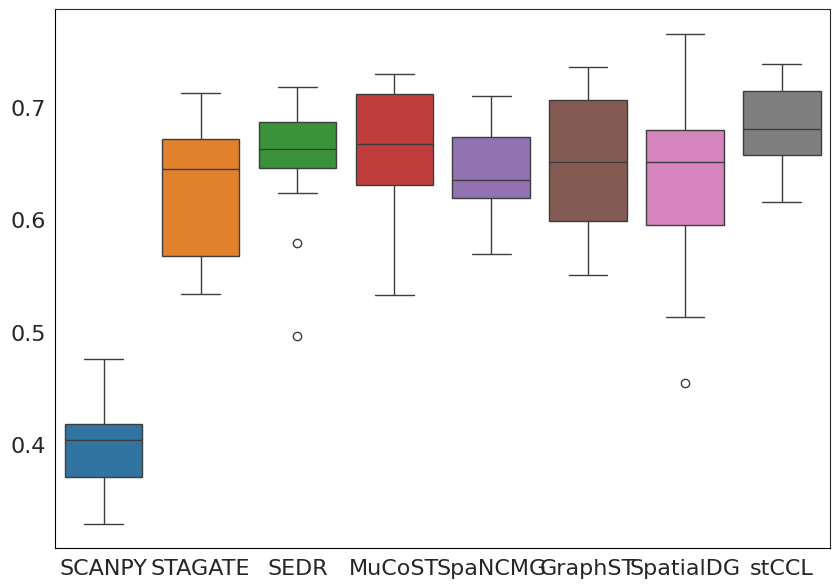

In [13]:
#绘制12张切片NMI的垂直箱线图和散点图
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import os

# 设置颜色和字体
sns.set_style("white")  # 设置背景为白色
colors = sns.color_palette(n_colors=7)
mpl.rcParams.update({'font.size': 16})
# 创建图像（设置图像大小）
plt.figure(figsize=(10,7))  # 宽 10 英寸，高 8 英寸

# 绘制垂直箱线图
ax = sns.boxplot(data=df2, orient='v')

# 计算均值
mean = df2.mean()
# 清空 y 轴标签（不是必须）
ax.set_xlabel('', labelpad=50)
# ax.set_title("ARI")
# 设置边框样式
ax.spines['top'].set_visible(True)    # 移除上边框
ax.spines['right'].set_visible(True)  # 移除右边框
ax.spines['bottom'].set_visible(True)  # 保留下边框
ax.spines['left'].set_visible(True)    # 保留左边框

# 设置边框颜色为黑色
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# 保存图像
plt.savefig(os.path.join(result_path, "DLPFC_NMI_v_box_strip3.png"), bbox_inches='tight')

# 显示图形
plt.show()

In [14]:

df2.median()

SCANPY       0.403700
STAGATE      0.645146
SEDR         0.662695
MuCoST       0.666935
SpaNCMG      0.634835
GraphST      0.650862
SpatialDG    0.651188
stCCL        0.680353
dtype: float64

/tmp/ipykernel_1636321/2403516211.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=mean_values.index, y=mean_values.values, palette='Set2')


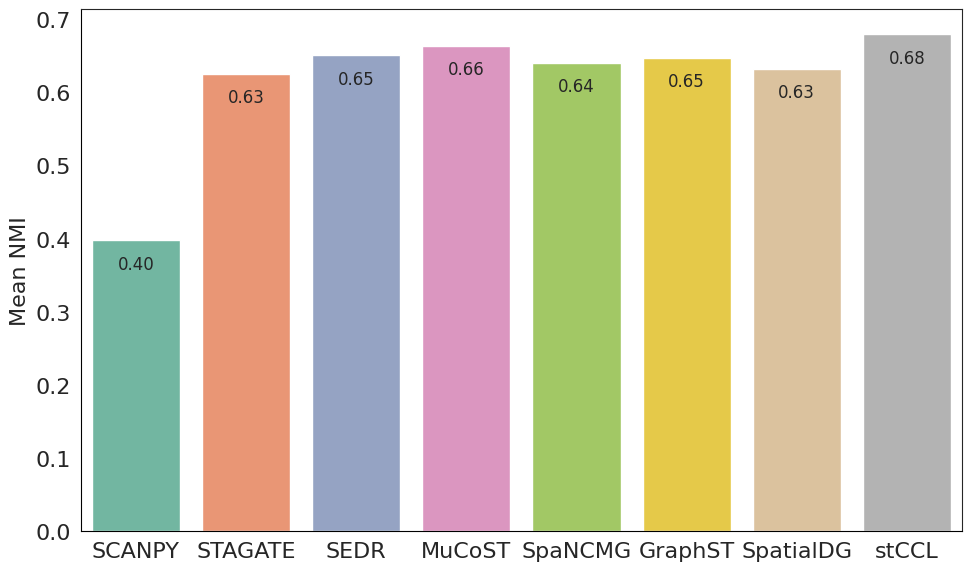

In [15]:
#绘制12张切片NMI均值的柱状图
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 计算每列的均值
mean_values = df2.mean()

# 创建图像并设置大小
# 设置颜色和字体
sns.set_style("white")  # 设置背景为白色
colors = sns.color_palette(n_colors=7)
mpl.rcParams.update({'font.size': 16})
plt.figure(figsize=(10, 6))

# 绘制柱状图
ax = sns.barplot(x=mean_values.index, y=mean_values.values, palette='Set2')

# 添加标题和标签
# plt.title("Mean ARI Values for Each Method", fontsize=18)
plt.xlabel("")
plt.ylabel("Mean NMI")

# 旋转 x 轴标签
# plt.xticks(rotation=45, ha='right')
ax.set_xlabel('', labelpad=50)
# 添加每个柱子的数值标签
for i, value in enumerate(mean_values.values):
    ax.text(i, value - 0.02, f"{value:.2f}", ha='center', va='top', fontsize=12)

# 自动调整布局防止遮挡
plt.tight_layout()
# 设置边框样式
ax.spines['top'].set_visible(True)    # 移除上边框
ax.spines['right'].set_visible(True)  # 移除右边框
ax.spines['bottom'].set_visible(True)  # 保留下边框
ax.spines['left'].set_visible(True)    # 保留左边框

# 设置边框颜色为黑色
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# 保存图像
plt.savefig(os.path.join(result_path, "DLPFC_MeanNMI_bar3.png"), bbox_inches='tight')

# 显示图形
plt.show()


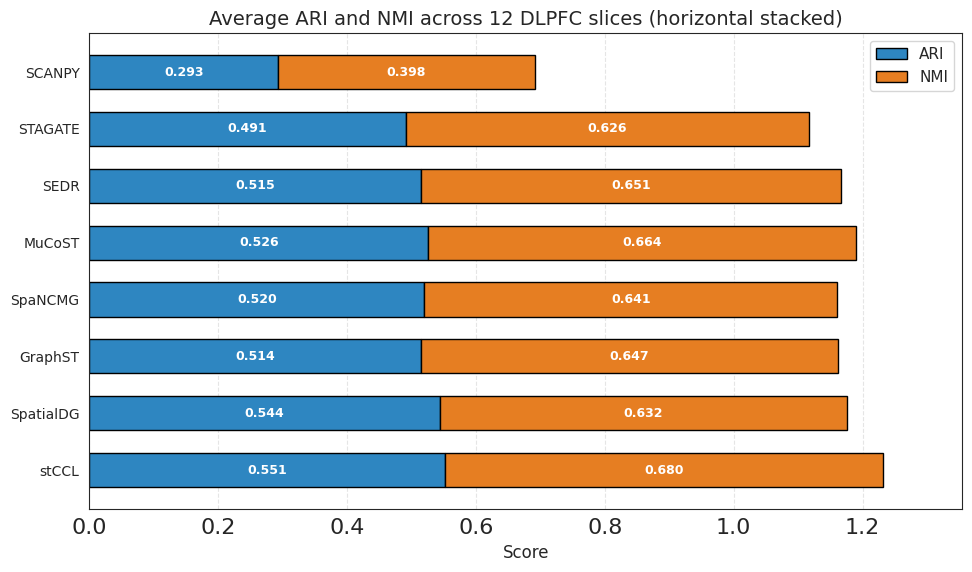

水平堆叠柱状图已保存至: /home/ZHX/code111/GraphST-main/final_result/result_visualization3/horizontal_stacked_ARI_NMI.png


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

# ========== 配置 ==========
excel_path = '/home/ZHX/code111/GraphST-main/final_result/DLPFC_result3.xlsx'
result_dir = '/home/ZHX/code111/GraphST-main/final_result/result_visualization3/'
Path(result_dir).mkdir(parents=True, exist_ok=True)

# ========== 读取数据（行=切片，列=方法） ==========
df_ari = pd.read_excel(excel_path, sheet_name='ARI', index_col=0)
df_nmi = pd.read_excel(excel_path, sheet_name='NMI', index_col=0)

# 获取方法列表（保持原始顺序）
methods = df_ari.columns.tolist()
df_ari = df_ari[methods]
df_nmi = df_nmi[methods]

# 计算各方法的均值（列均值）
mean_ari = df_ari.mean(axis=0)
mean_nmi = df_nmi.mean(axis=0)

# ========== 绘制水平堆叠条形图 ==========
fig, ax = plt.subplots(figsize=(10, 6))

y = np.arange(len(methods))
height = 0.6

# 绘制 ARI（左侧）和 NMI（右侧，堆叠在 ARI 之上）
bars_ari = ax.barh(y, mean_ari, height, label='ARI', color='#2E86C1', edgecolor='black')
bars_nmi = ax.barh(y, mean_nmi, height, left=mean_ari, label='NMI', color='#E67E22', edgecolor='black')

# 颠倒纵轴顺序：使第一个方法在底部，最后一个在顶部
ax.invert_yaxis()

# 在堆叠各部分内部添加数值标签
for i, (ari, nmi) in enumerate(zip(mean_ari, mean_nmi)):
    ax.text(ari/2, i, f'{ari:.3f}', ha='center', va='center', color='white', fontsize=9, fontweight='bold')
    ax.text(ari + nmi/2, i, f'{nmi:.3f}', ha='center', va='center', color='white', fontsize=9, fontweight='bold')

# 设置纵坐标刻度标签为方法名称
ax.set_yticks(y)
ax.set_yticklabels(methods, fontsize=10)
ax.set_xlabel('Score', fontsize=12)
ax.set_title('Average ARI and NMI across 12 DLPFC slices (horizontal stacked)', fontsize=14)

ax.legend(fontsize=11)

# 横坐标刻度间隔为 0.2
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
max_total = (mean_ari + mean_nmi).max()
xlim_max = max(max_total * 1.1, 1.0)
ax.set_xlim(0, xlim_max)

ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(result_dir + 'horizontal_stacked_ARI_NMI.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("水平堆叠柱状图已保存至:", result_dir + 'horizontal_stacked_ARI_NMI.png')